In [2]:
import torch
from torch.optim import Adam
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('data/cars.csv', index_col='Unnamed: 0')
df

In [4]:
w = torch.empty( 1,requires_grad=True)
b = torch.empty( 1,requires_grad=True)
torch.nn.init.uniform_(w)
torch.nn.init.uniform_(b)

tensor([0.1304], requires_grad=True)

In [7]:
x = torch.FloatTensor( df['speed'].values )
y = torch.FloatTensor( df['dist'].values )

In [8]:
def cost():
    hx = w*x + b
    c = torch.mean( (hx-y)**2 )
    return c

In [ ]:
optimizer = Adam( [w,b], lr=0.01 )
for epoch in range( 2000 ):
    c = cost()
    optimizer.zero_grad()
    c.backward()
    optimizer.step()
    print( 'cost:', c.item())

In [16]:
def hxFn( xd ):
    xd = torch.FloatTensor( xd )
    hx = w*xd + b
    print( type( hx ))
    return hx.detach().numpy()

In [12]:
hxFn( 15 )

<class 'torch.Tensor'>


array([43.146774], dtype=float32)

In [17]:
hxFn( [15,20] )

<class 'torch.Tensor'>


array([43.146774, 58.60658 ], dtype=float32)

In [ ]:
pred = hxFn( x )
pred

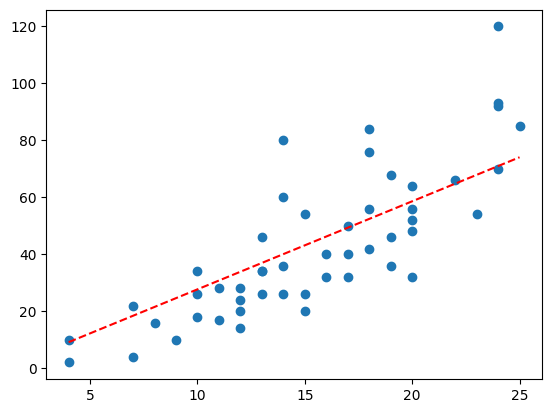

In [20]:
plt.scatter( x,y )
plt.plot( x, pred ,'r--')
plt.show()